In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

In [7]:
# Function to get best polynomial fit
def best_polyfit(x, y):
    best_mse_polyfit = None
    best_r_squared_pf = None
    best_degree = None
    best_polyfit = None
    
    for d in range(1, len(x) - 1):
        coefficients = np.polyfit(x, y, d)
        polynomial = np.poly1d(coefficients)
        y_polyfit = polynomial(x)

        # MSE and R-squared
        msePolyfit = np.mean((y - y_polyfit)**2)
        ss_total = np.sum((y - np.mean(y))**2)
        ss_res_pf = np.sum((y - y_polyfit)**2)
        r_squared_pf = 1 - (ss_res_pf / ss_total)
    
        if best_polyfit is None or ((msePolyfit < best_mse_polyfit) 
                                    and (r_squared_pf > best_r_squared_pf)):
            best_mse_polyfit = msePolyfit
            best_r_squared_pf = r_squared_pf
            best_degree = d
            best_polyfit = polynomial
    return best_degree, best_polyfit

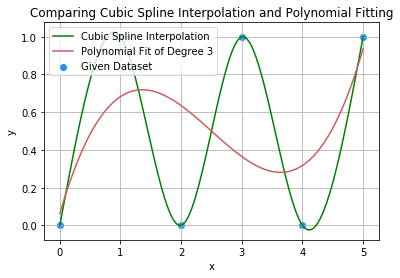

In [8]:
x = np.array([0, 1, 2, 3, 4, 5])
x_smooth = np.linspace(0, 5, 100) # x-values for smooth plotting
y = np.array([0, 1, 0, 1, 0, 1])

# Cubic spline interpolation
cs = CubicSpline(x, y, bc_type='natural')
y_interp = cs(x_smooth)

# Polynomial fit
pf_degree, pf = best_polyfit(x, y)
y_pf = pf(x_smooth)

# Plotting
plt.figure()
plt.scatter(x, y, color='dodgerblue', label="Given Dataset")
plt.plot(x_smooth, y_interp, color='green', label="Cubic Spline Interpolation")
plt.plot(x_smooth, y_pf, color='indianred', label=f"Polynomial Fit of Degree {pf_degree}")
plt.title("Comparing Cubic Spline Interpolation and Polynomial Fitting")
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid()
plt.show()

In [9]:
"""
Even after using my best_polyfit() function to determine the best degree to
use for the polynomial fitting method, it's clear that the cubic spline
interpolation method resulted in a much more accurate model of the dataset.
"""

"\nEven after using my best_polyfit() function to determine the best degree to\nuse for the polynomial fitting method, it's clear that the cubic spline\ninterpolation method resulted in a much more accurate model of the dataset.\n"